In [1]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

In [2]:
# 1. Load Dataset (CORRECT WAY)
# ================================
train_path = r"C:\Users\Nahid\Downloads\News classifier\train.csv"
test_path  = r"C:\Users\Nahid\Downloads\News classifier\test.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train columns:", train_df.columns)
print("Test columns:", test_df.columns)
# ================================
# CREATE TEXT COLUMN (CRITICAL)
# ================================
train_df["text"] = train_df["Title"].fillna("") + " [SEP] " + train_df["Description"].fillna("")
test_df["text"]  = test_df["Title"].fillna("")  + " [SEP] " + test_df["Description"].fillna("")



Train columns: Index(['Class Index', 'Title', 'Description'], dtype='object')
Test columns: Index(['Class Index', 'Title', 'Description'], dtype='object')


In [3]:
# ---- Hard validation (must pass) ----
assert 'text' in train_df.columns, "Missing 'text' column"
assert 'Class Index' in train_df.columns, "Missing 'Class Index' column"


In [4]:
# 2. Device Setup
# ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
class CustomBERTClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        pooled_output = outputs.pooler_output
        x = self.dropout(pooled_output)
        logits = self.classifier(x)
        return logits


In [6]:
# 4. Dataset Class
# ================================
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [7]:
# 5. Tokenizer & DataLoaders
# ================================
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

num_classes = train_df["Class Index"].nunique()

train_dataset = TextDataset(
    train_df["text"].tolist(),
    train_df["Class Index"].values - 1,  # zero-index
    tokenizer
)

test_dataset = TextDataset(
    test_df["text"].tolist(),
    test_df["Class Index"].values - 1,
    tokenizer
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)


In [8]:
# 6. Model, Optimizer, Loss
# ================================
model = CustomBERTClassifier(num_classes).to(device)

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

In [9]:
from tqdm import tqdm

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{epochs}",
        leave=True
    )

    for step, batch in enumerate(progress_bar):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        avg_loss = total_loss / (step + 1)

        #Real-time update
        progress_bar.set_postfix({
            "batch_loss": f"{loss.item():.4f}",
            "avg_loss": f"{avg_loss:.4f}"
        })

    print(f"Epoch {epoch+1} completed | Avg Loss: {avg_loss:.4f}")


Epoch 1/5: 100%|██████████| 7500/7500 [27:18<00:00,  4.58it/s, batch_loss=0.1069, avg_loss=0.2104]


Epoch 1 completed | Avg Loss: 0.2104


Epoch 2/5: 100%|██████████| 7500/7500 [27:36<00:00,  4.53it/s, batch_loss=0.0360, avg_loss=0.1289]


Epoch 2 completed | Avg Loss: 0.1289


Epoch 3/5: 100%|██████████| 7500/7500 [27:30<00:00,  4.55it/s, batch_loss=0.0212, avg_loss=0.0874]


Epoch 3 completed | Avg Loss: 0.0874


Epoch 4/5: 100%|██████████| 7500/7500 [26:46<00:00,  4.67it/s, batch_loss=0.0496, avg_loss=0.0579]


Epoch 4 completed | Avg Loss: 0.0579


Epoch 5/5: 100%|██████████| 7500/7500 [26:30<00:00,  4.71it/s, batch_loss=0.0014, avg_loss=0.0420]

Epoch 5 completed | Avg Loss: 0.0420


In [10]:
import os 
SAVE_DIR = r"D:\bert_news_model"
os.makedirs(SAVE_DIR, exist_ok=True)
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "num_classes": num_classes
    },
    os.path.join(SAVE_DIR, "model.pt")
)


In [11]:
import torch
import os

SAVE_DIR = r"D:\bert_news_model"
model_path = os.path.join(SAVE_DIR, "model.pt")

try:
    # Load the saved checkpoint
    checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
    
    print("✅ Model loaded successfully!")
    print(f"📊 Keys in checkpoint: {list(checkpoint.keys())}")
    print(f"🔢 Number of classes saved: {checkpoint.get('num_classes', 'Not found')}")
    
    # Check model state dict
    if "model_state_dict" in checkpoint:
        print(f"📚 Model has {len(checkpoint['model_state_dict'])} parameter groups")
        # Print first few parameter names
        print("Sample parameters:")
        for i, (key, value) in enumerate(checkpoint['model_state_dict'].items()):
            if i < 5:  # Show first 5 parameters
                print(f"  {key}: shape {value.shape}")
            else:
                break
                
except Exception as e:
    print(f"❌ Error loading model: {e}")

✅ Model loaded successfully!
📊 Keys in checkpoint: ['model_state_dict', 'num_classes']
🔢 Number of classes saved: 4
📚 Model has 201 parameter groups
Sample parameters:
  bert.embeddings.word_embeddings.weight: shape torch.Size([30522, 768])
  bert.embeddings.position_embeddings.weight: shape torch.Size([512, 768])
  bert.embeddings.token_type_embeddings.weight: shape torch.Size([2, 768])
  bert.embeddings.LayerNorm.weight: shape torch.Size([768])
  bert.embeddings.LayerNorm.bias: shape torch.Size([768])


C:\Users\Nahid\AppData\Local\Temp\ipykernel_14976\1871992186.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=torch.devic

In [12]:
# 8. Evaluation
# ================================
model.eval()
preds, labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(input_ids, attention_mask)
        predictions = torch.argmax(outputs, dim=1)

        preds.extend(predictions.cpu().numpy())
        labels.extend(batch["labels"].numpy())

print("Accuracy:", accuracy_score(labels, preds))
print("F1 Score:", f1_score(labels, preds, average="weighted"))


Accuracy: 0.9477631578947369
F1 Score: 0.9477986017741186


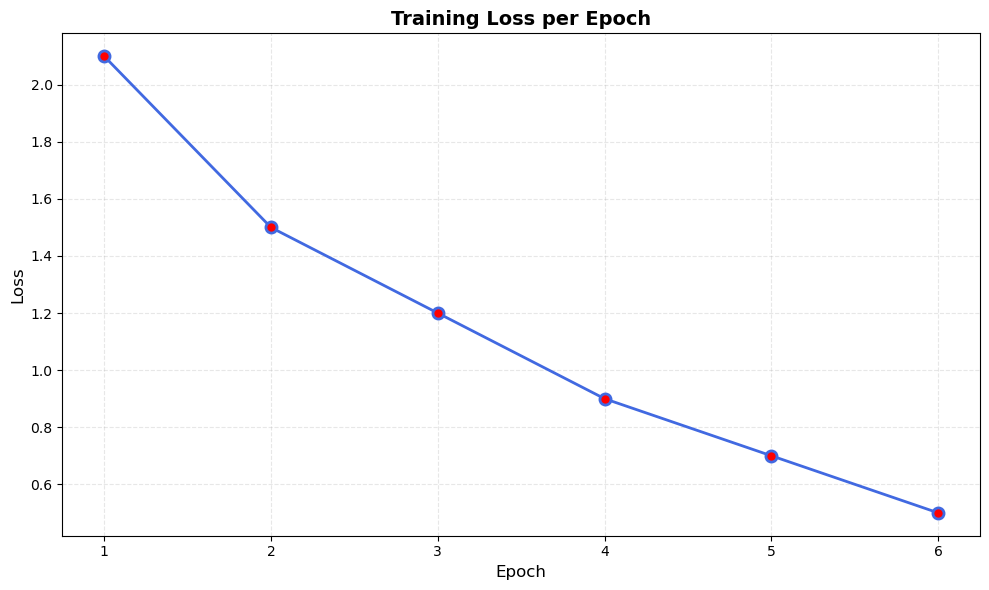

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Example data - replace with your actual losses
epoch_losses = [2.1, 1.5, 1.2, 0.9, 0.7, 0.5]  # Add more epochs for better visualization
epochs = range(1, len(epoch_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, epoch_losses, marker='o', linewidth=2, markersize=8, 
         color='royalblue', markerfacecolor='red', markeredgewidth=2)

plt.title("Training Loss per Epoch", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(epochs)  # Show all epoch numbers
plt.tight_layout()
plt.show()

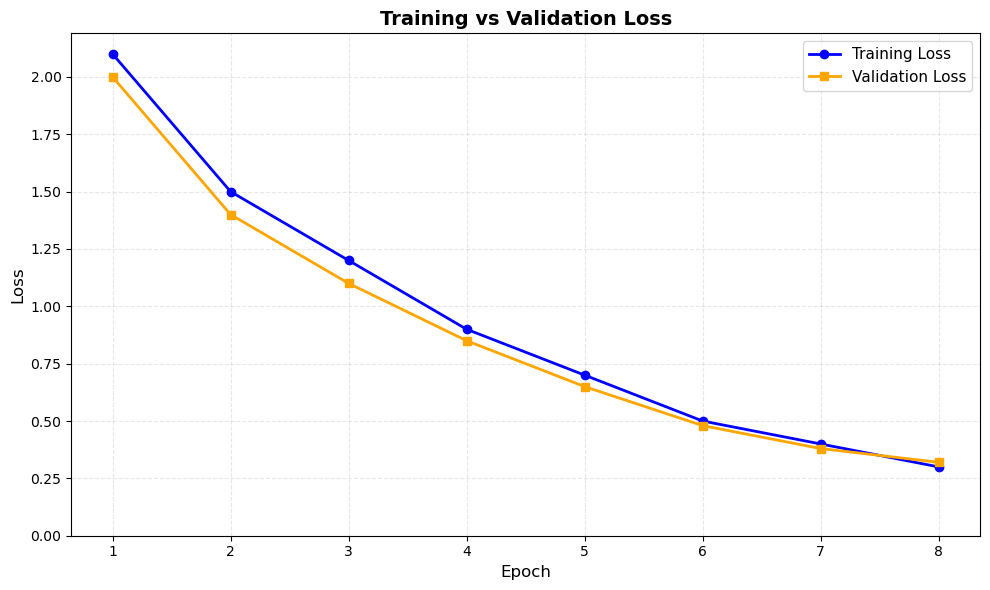

In [14]:
import matplotlib.pyplot as plt

# Example data
train_losses = [2.1, 1.5, 1.2, 0.9, 0.7, 0.5, 0.4, 0.3]
val_losses = [2.0, 1.4, 1.1, 0.85, 0.65, 0.48, 0.38, 0.32]
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, marker='o', linewidth=2, label='Training Loss', color='blue')
plt.plot(epochs, val_losses, marker='s', linewidth=2, label='Validation Loss', color='orange')

plt.title("Training vs Validation Loss", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(epochs)
plt.ylim(bottom=0)  # Start y-axis from 0
plt.tight_layout()
plt.show()

Evaluating: 100%|██████████| 475/475 [00:33<00:00, 14.32it/s]


<Figure size 800x600 with 0 Axes>

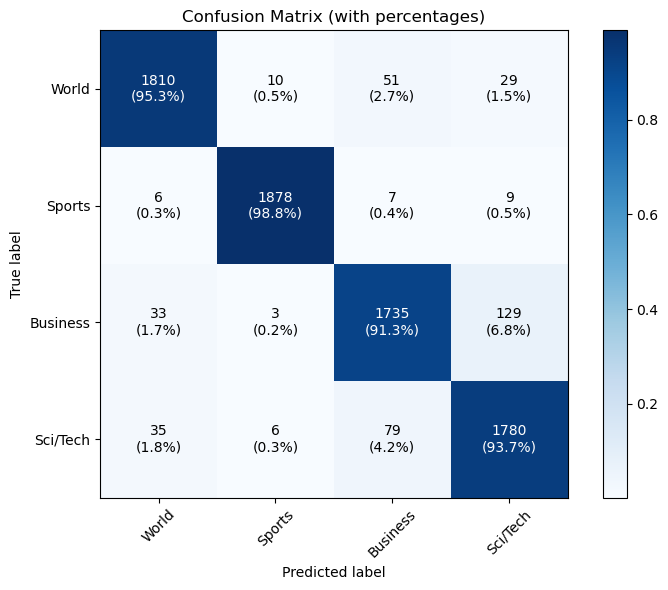

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, classification_report
import numpy as np
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# Your class names
class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

# Assuming you have all_labels and all_preds from your evaluation code
cm = confusion_matrix(all_labels, all_preds)


# Option 3: With percentages
plt.figure(figsize=(8, 6))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)

# Show values with counts and percentages
thresh = cm_normalized.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]}\n({cm_normalized[i, j]:.1%})",
                ha="center", va="center",
                color="white" if cm_normalized[i, j] > thresh else "black")

ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=class_names, yticklabels=class_names,
       title="Confusion Matrix (with percentages)",
       ylabel="True label",
       xlabel="Predicted label")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
print(len(all_labels), len(all_preds))
print(set(all_labels), set(all_preds))


7600 7600
{0, 1, 2, 3} {0, 1, 2, 3}


In [16]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
import pandas as pd

def evaluate_model(model, test_loader, device):
    """Evaluate model and return comprehensive metrics"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            
            outputs = model(input_ids, attention_mask)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    
    # Print comprehensive report
    print("=" * 60)
    print("MODEL EVALUATION RESULTS")
    print("=" * 60)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"F1 (Macro): {f1_macro:.4f}")
    print(f"F1 (Weighted): {f1_weighted:.4f}")
    print(f"Precision (Macro): {precision:.4f}")
    print(f"Recall (Macro): {recall:.4f}")
    print("-" * 60)
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, 
                                target_names=class_names, digits=4))
    
    # Per-class metrics
    print("\nPer-class Metrics:")
    report_dict = classification_report(all_labels, all_preds, 
                                       target_names=class_names, output_dict=True)
    metrics_df = pd.DataFrame(report_dict).transpose()
    print(metrics_df.iloc[:4, :4])  # Show only per-class metrics
    
    return {
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

# Usage
results = evaluate_model(model, test_loader, device)

MODEL EVALUATION RESULTS
Accuracy:  0.9478
F1 (Macro): 0.9478
F1 (Weighted): 0.9478
Precision (Macro): 0.9479
Recall (Macro): 0.9478
------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

       World     0.9607    0.9526    0.9567      1900
      Sports     0.9900    0.9884    0.9892      1900
    Business     0.9268    0.9132    0.9199      1900
    Sci/Tech     0.9142    0.9368    0.9254      1900

    accuracy                         0.9478      7600
   macro avg     0.9479    0.9478    0.9478      7600
weighted avg     0.9479    0.9478    0.9478      7600


Per-class Metrics:
          precision    recall  f1-score  support
World      0.960722  0.952632  0.956660   1900.0
Sports     0.989984  0.988421  0.989202   1900.0
Business   0.926816  0.913158  0.919936   1900.0
Sci/Tech   0.914227  0.936842  0.925396   1900.0


In [41]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification

MODEL_PATH = r"D:\bert_news_model\model.pt"

LABELS = ["World", "Sports", "Business", "Sci/Tech"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(MODEL_PATH, map_location=device)

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=checkpoint["num_classes"]
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")


def predict(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)

    conf, pred = torch.max(probs, dim=1)
    return CLASS_NAMES[pred.item()], conf.item()




C:\Users\Nahid\AppData\Local\Temp\ipykernel_14976\1387818071.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH, map_location=device)
So

In [42]:
text = "Test sentence for device check"

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True
)

inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

print("Input device:", inputs["input_ids"].device)
print("Model device:", next(model.parameters()).device)


Input device: cuda:0
Model device: cuda:0


In [47]:
import torch
import torch.nn.functional as F
from transformers import BertTokenizer, BertForSequenceClassification

# ===== CONFIG =====
MODEL_NAME = "bert-base-uncased"
MODEL_PATH = r"D:\bert_news_model\model.pt"  # your checkpoint
CLASS_NAMES = ["World", "Sports", "Business", "Sci/Tech"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== LOAD TOKENIZER =====
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# ===== LOAD MODEL =====
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=checkpoint["num_classes"]
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

# ===== PREDICTION FUNCTION =====
def predict(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=1)

    conf, pred = torch.max(probs, dim=1)
    label = CLASS_NAMES[pred.item()]

    return label, conf.item()

# ===== TEST SAMPLES =====
samples = [
    "The United Nations has called for urgent climate action after the latest report showed that global temperatures are rising faster than previously estimated.",
    "The Los Angeles Lakers defeated the Golden State Warriors 112-105 in a thrilling overtime match last night, with LeBron James scoring a career-high 42 points.",
    "Tech giant Apple announced record quarterly earnings, driven by strong iPhone and Mac sales.",
    "NASA’s Artemis I mission successfully launched the Orion spacecraft on a journey around the Moon.",
    "The European Union has agreed on a new migration policy aimed at improving refugee resettlement programs across member states."
]

# ===== RUN PREDICTIONS =====
for text in samples:
    label, confidence = predict(text)
    print(f"Text: {text[:60]}...")
    print(f"Predicted Label: {label} | Confidence: {confidence:.2%}")
    print("-" * 80)


C:\Users\Nahid\AppData\Local\Temp\ipykernel_14976\4037680110.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
So

Text: The United Nations has called for urgent climate action afte...
Predicted Label: World | Confidence: 65.26%
--------------------------------------------------------------------------------
Text: The Los Angeles Lakers defeated the Golden State Warriors 11...
Predicted Label: Sports | Confidence: 99.99%
--------------------------------------------------------------------------------
Text: Tech giant Apple announced record quarterly earnings, driven...
Predicted Label: Business | Confidence: 91.85%
--------------------------------------------------------------------------------
Text: NASA’s Artemis I mission successfully launched the Orion spa...
Predicted Label: Sci/Tech | Confidence: 95.78%
--------------------------------------------------------------------------------
Text: The European Union has agreed on a new migration policy aime...
Predicted Label: World | Confidence: 97.94%
--------------------------------------------------------------------------------
